# K-Means Clustering Project – Facebook Live Dataset

## Objective
Apply **K-Means Clustering**, an unsupervised machine-learning algorithm, to group Facebook Live posts according to their engagement characteristics.

**Dataset:** `Live.csv`

> In this revised notebook, `status_type` is kept for interpretation only and is **not used as a target variable**. K-Means is unsupervised, so comparing cluster labels directly with `status_type` as an "accuracy" score is not appropriate.

#### 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

#### 2. Import dataset

In [2]:
df = pd.read_csv("Live.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7050, 16)


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


#### 3. Exploratory Data Analysis

In [3]:
df.shape

(7050, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [5]:
# Check missing values
df.isnull().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

In [6]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_reactions,7050.0,230.117163,462.625309,0.0,17.0,59.5,219.00,4710.0
num_comments,7050.0,224.356028,889.636820,0.0,0.0,4.0,23.00,20990.0
num_shares,7050.0,40.022553,131.599965,0.0,0.0,0.0,4.00,3424.0
num_likes,7050.0,215.043121,449.472357,0.0,17.0,58.0,184.75,4710.0
num_loves,7050.0,12.728652,39.972930,0.0,0.0,0.0,3.00,657.0
num_wows,7050.0,1.289362,8.719650,0.0,0.0,0.0,0.00,278.0
num_hahas,7050.0,0.696454,3.957183,0.0,0.0,0.0,0.00,157.0
num_sads,7050.0,0.243688,1.597156,0.0,0.0,0.0,0.00,51.0
num_angrys,7050.0,0.113191,0.726812,0.0,0.0,0.0,0.00,31.0
Column1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Distribution of post types
df["status_type"].value_counts()

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64

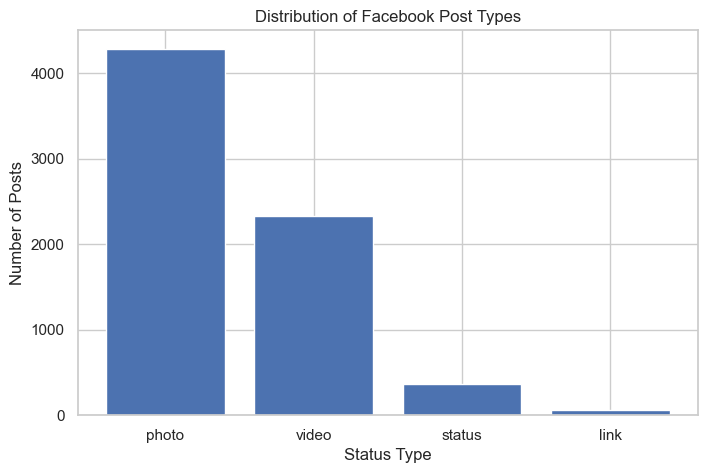

In [8]:
counts = df["status_type"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title("Distribution of Facebook Post Types")
plt.xlabel("Status Type")
plt.ylabel("Number of Posts")
plt.show()

#### 4. Data Preparation

The dataset contains:
- `status_id` and `status_published`: identifier/time-text fields that are not suitable for numerical clustering.
- `Column1`–`Column4`: empty/redundant columns in this dataset.
- `status_type`: categorical information about the post type. It is retained for later interpretation, but it is not used to form the clusters.
- Engagement variables such as reactions, comments, shares and different reaction types are used as clustering features.

In [9]:
# Create a copy
data = df.copy()

# Remove identifier/text fields and empty redundant columns
drop_cols = [
    "status_id", "status_published",
    "Column1", "Column2", "Column3", "Column4"
]
data.drop(columns=drop_cols, inplace=True)

data.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,529,512,262,432,92,3,1,1,0
1,photo,150,0,0,150,0,0,0,0,0
2,video,227,236,57,204,21,1,1,0,0
3,photo,111,0,0,111,0,0,0,0,0
4,photo,213,0,0,204,9,0,0,0,0


In [10]:
# Select numerical engagement features only
features = [
    "num_reactions", "num_comments", "num_shares",
    "num_likes", "num_loves", "num_wows",
    "num_hahas", "num_sads", "num_angrys"
]

X = data[features].copy()

print("Features used for clustering:")
print(features)
print("\nMissing values:")
print(X.isnull().sum())

Features used for clustering:
['num_reactions', 'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']

Missing values:
num_reactions    0
num_comments     0
num_shares       0
num_likes        0
num_loves        0
num_wows         0
num_hahas        0
num_sads         0
num_angrys       0
dtype: int64


#### 5. Feature Transformation and Scaling

Engagement counts are highly skewed because a small number of posts can have very large engagement values. We therefore use `log1p()` before standardization.

`StandardScaler` puts the transformed features on a comparable scale so that variables with larger numerical values do not dominate the distance calculation.

In [11]:
# Handle missing values, if any
X = X.fillna(X.median())

# Reduce strong right-skew in count variables
X_log = np.log1p(X)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1.246928,1.719741,2.313934,1.188102,2.392021,1.613824,0.862031,1.711468,-0.229904
1,0.518728,-0.951446,-0.641597,0.565108,-0.636607,-0.474460,-0.380746,-0.268881,-0.229904
2,0.757711,1.389190,1.512106,0.745911,1.428790,0.569682,0.862031,-0.268881,-0.229904
3,0.345446,-0.951446,-0.641597,0.388415,-0.636607,-0.474460,-0.380746,-0.268881,-0.229904
4,0.720959,-0.951446,-0.641597,0.745911,0.901952,-0.474460,-0.380746,-0.268881,-0.229904


#### 6. Find the Optimal Number of Clusters – Elbow Method

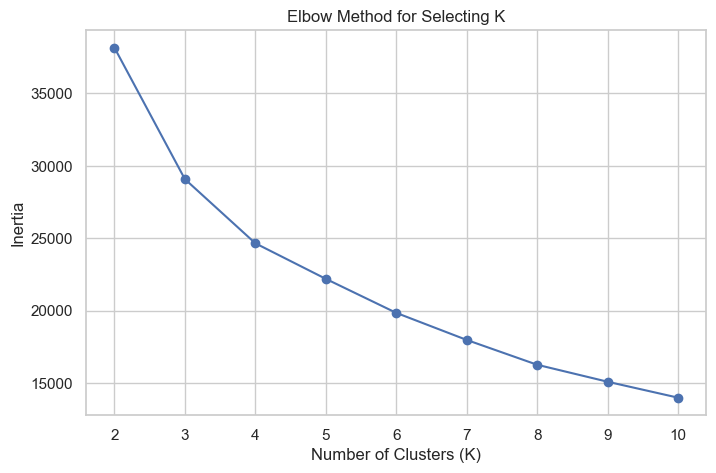

In [12]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method for Selecting K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

**Interpretation:** The elbow plot shows how within-cluster variation decreases as K increases. The elbow is used as one indication of a suitable K; it should be considered together with a cluster-quality measure such as the silhouette score.

#### 7. Silhouette Score

In [14]:
silhouette_scores = {}

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

silhouette_scores

{2: 0.5346217786952372,
 3: 0.3869640605457693,
 4: 0.3914226097838153,
 5: 0.3774427335805232,
 6: 0.38384950517878447,
 7: 0.29979304906275167,
 8: 0.30730382316884425,
 9: 0.3119378450025823,
 10: 0.3209849535710834}

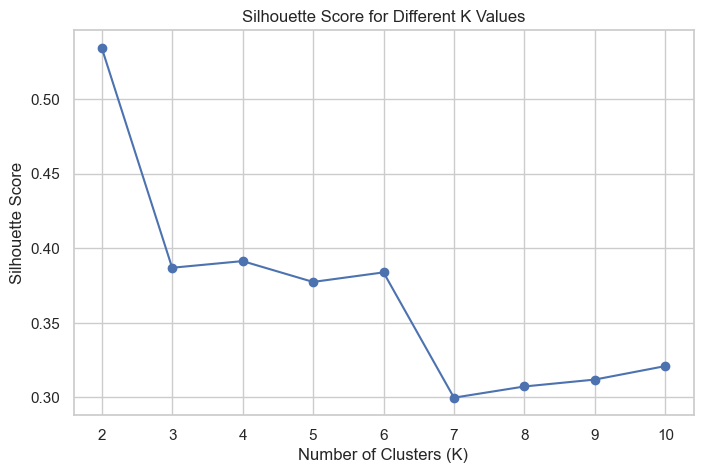

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

In [16]:
# Select the K with the highest silhouette score
optimal_k = max(silhouette_scores, key=silhouette_scores.get)

print("Optimal K based on highest silhouette score:", optimal_k)
print("Silhouette score:", round(silhouette_scores[optimal_k], 4))

Optimal K based on highest silhouette score: 2
Silhouette score: 0.5346


#### 8. Build the Final K-Means Model

In [17]:
kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    n_init=10,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Number of clusters:", optimal_k)
print("Final inertia:", round(kmeans.inertia_, 2))
print("Final silhouette score:", round(silhouette_score(X_scaled, cluster_labels), 4))

Number of clusters: 2
Final inertia: 38147.74
Final silhouette score: 0.5346


#### 9. Add Cluster Labels to the Dataset

In [18]:
result = data.copy()
result["Cluster"] = cluster_labels

result.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Cluster
0,video,529,512,262,432,92,3,1,1,0,1
1,photo,150,0,0,150,0,0,0,0,0,0
2,video,227,236,57,204,21,1,1,0,0,1
3,photo,111,0,0,111,0,0,0,0,0,0
4,photo,213,0,0,204,9,0,0,0,0,0


In [19]:
# Number of records in each cluster
cluster_counts = result["Cluster"].value_counts().sort_index()
cluster_counts

Cluster
0    5685
1    1365
Name: count, dtype: int64

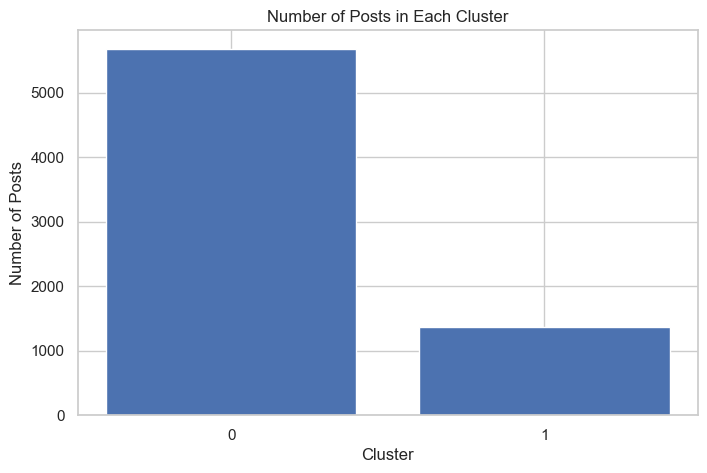

In [20]:
cluster_counts = result["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Number of Posts in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Posts")
plt.show()

#### 10. Cluster Profile

In [21]:
# Mean engagement values for each cluster
cluster_profile = result.groupby("Cluster")[features].mean().round(2)
cluster_profile

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
Cluster,,,,,,,,,
0,172.62,9.04,1.86,171.34,0.87,0.28,0.06,0.07,0.01
1,469.57,1121.11,198.98,397.07,62.12,5.48,3.36,0.99,0.54


In [22]:
# Median engagement values are also useful because engagement is skewed
cluster_median = result.groupby("Cluster")[features].median().round(2)
cluster_median

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
Cluster,,,,,,,,,
0,34.0,2.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0
1,258.0,526.0,142.0,197.0,42.0,1.0,2.0,0.0,0.0


### Interpreting the clusters

Use the cluster profile above to describe the groups in terms of engagement. For example, a cluster with relatively high values across reactions, comments and shares can be described as a **high-engagement group**, while a cluster with consistently lower values can be described as a **low-engagement group**.

The cluster number itself (0, 1, …) has no inherent meaning; the profile of each cluster determines its interpretation.

#### 11. PCA Visualization of the Clusters

In [23]:
# Reduce the standardized feature space to two dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

print("Explained variance by PC1 and PC2:",
      round(pca.explained_variance_ratio_[0], 4),
      round(pca.explained_variance_ratio_[1], 4))
print("Total explained variance:",
      round(pca.explained_variance_ratio_.sum(), 4))

Explained variance by PC1 and PC2: 0.5579 0.148
Total explained variance: 0.7059


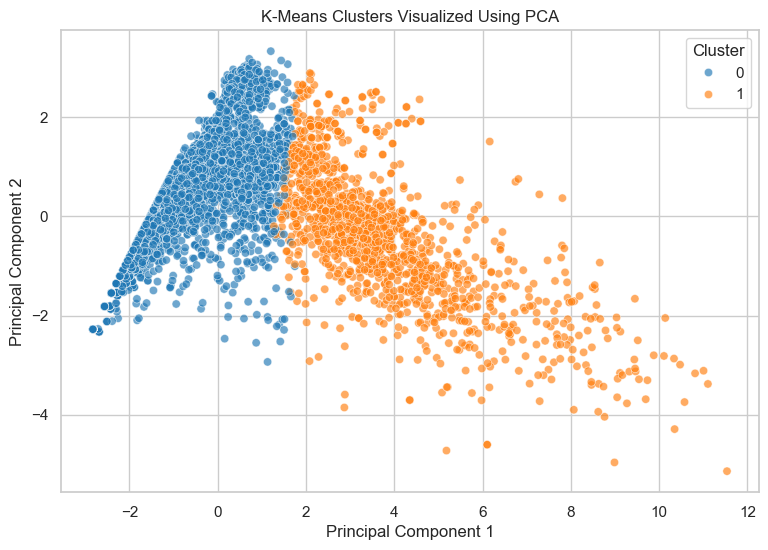

In [24]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.65
)
plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

#### 12. Optional Interpretation Using `status_type`

In [25]:
# This does NOT measure clustering accuracy.
# It only shows the distribution of post types inside each cluster.
cluster_status = pd.crosstab(
    result["Cluster"],
    result["status_type"],
    normalize="index"
).round(3)

cluster_status

status_type,link,photo,status,video
Cluster,,,,
0,0.011,0.711,0.058,0.220
1,0.000,0.179,0.026,0.795


In [ ]:
cluster_status.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Post-Type Composition of Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Status Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 13. Final Results and Conclusion

1. The Facebook Live dataset was loaded and explored.
2. Identifier/text fields and empty redundant columns were removed.
3. Engagement variables were selected as the features for clustering.
4. `log1p()` transformation and standardization were applied to reduce the effect of highly skewed engagement counts.
5. The Elbow Method and Silhouette Score were used to investigate the suitable number of clusters.
6. The final K-Means model was trained using the selected `K`.
7. Cluster sizes, cluster profiles and a PCA visualization were generated.
8. `status_type` was used only for post-clustering interpretation.

**Important:** K-Means is an unsupervised algorithm. Therefore, the cluster labels should not be treated as class labels, and a conventional classification accuracy such as `correct_labels / total_samples` is not an appropriate evaluation of K-Means. In this notebook, **inertia and silhouette score** are used to evaluate clustering quality.

## Key K-Means Concepts

- **Centroid:** Mean position of all observations in a cluster.
- **Inertia:** Sum of squared distances of observations from their assigned cluster centroid. Lower values generally indicate tighter clusters, but inertia always decreases as K increases.
- **Silhouette Score:** Measures how well each observation fits its own cluster compared with other clusters. Higher values generally indicate better-separated clusters.
- **Elbow Method:** Plots inertia against K and looks for a point where additional clusters provide diminishing improvement.
- **K-Means++:** Initialization strategy that generally gives better starting centroids than purely random initialization.
- **PCA:** Used here only to visualize high-dimensional clusters in two dimensions.